(sec:dimer-case1-qmt)=
# Quantum trajectory

## Counting emissions from each QD

We are interested in quantum jumps each of which emits a photon.  There are two such jumps which are associated with $\sigma^{-}_{1}$ and $\sigma^{-}_{2}$.  We discards absorption jumps since they cannot be detected by the detector.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# reset random number
rng = np.random.default_rng()

# system parameters
omega0 = 1.0   # excitation energy
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
NT = 1/(np.exp(omega0/temperature)-1) # Planck distribution

# basic operators
i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# free hamiltonian
H0 = 0.5*omega0*(sz[0]+sz[1])

# collapse operators
gamma1 = gamma0 * NT   # coefficient to absorption
gamma2 = gamma0 * (NT+1)  # coefficient to emission
c_ops = [np.sqrt(gamma1)*sm[0], np.sqrt(gamma1)*sm[1], np.sqrt(gamma2)*sp[0], np.sqrt(gamma2)*sp[1]]

# we measure jump count of system 1, 2 and total
n1 = sp[0] * sm[0]
n2 = sp[1] * sm[1]
e_ops = [n1, n2, n1 + n2]

# initially in the ground state
psi0 = tensor(basis(2,1),basis(2,1))

# execution time (trying to get 1000 photons)
tmax = 2000 / gamma2
# number of time sampling points
tsample = 4000
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H0,psi0,times,c_ops,e_ops=e_ops,ntraj=1,options=opts)

# get results
t_jump = np.array(result.col_times[0]) # time of all jumps
ch_jump = np.array(result.col_which[0]) # channel of all jumps

# emission time for each quantum dot
t_emission_1 = t_jump[ch_jump==0]
t_emission_2 = t_jump[ch_jump==1]
t_emission_all = t_jump[(ch_jump==0) | (ch_jump==1)]

# is there enough counts?
print("Number of emission jumps in system 1 =", len(t_emission_1))
print("Number of emission jumps in system 2 =", len(t_emission_2))
print("Total number of emission jumps       =", len(t_emission_all))


Number of emission jumps in system 1 = 537
Number of emission jumps in system 2 = 538
Total number of emission jumps       = 1075


## Spikes

Now, we plot spike trains for each channel and total. Only first 200 time unit is plotted.

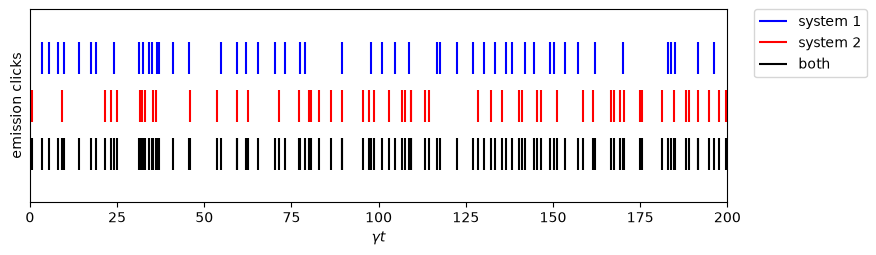

In [8]:
# ---------- spike train ----------
plt.figure(figsize=(9, 2.5))

# emissions: detector clicks
plt.vlines(t_emission_1 * gamma2, 1.2, 1.6, color="b", label="system 1")
plt.vlines(t_emission_2 * gamma2, 0.6, 1.0, color="r", label="system 2")
plt.vlines(t_emission_all * gamma2, 0.0, 0.4, color="k",  label="both")
plt.ylabel("emission clicks")
plt.xlabel(r"$\gamma t$")
plt.xlim([0,200])
plt.ylim(-0.4, 2.0)
plt.yticks([])
plt.legend(bbox_to_anchor=(1.20, 1), borderaxespad=0)
plt.show()

## Waiting time distribution

Next, we plot the waiting distribution.

In [9]:

#def wating_time_distribution(spikes):

def waiting_time(spikes):
    wtime = np.array([])
    for i in range(len(spikes)-1):
        wtime = np.append(wtime,spikes[i+1]-spikes[i])
        
    mean = sum(wtime)/len(wtime)
    dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

    print("mean waiting time  = ",mean)
    print("standard deviation = ",dev)

    if dev < 0.9*mean:
        print("likely sub-poissonian")
    elif dev > 1.1*mean:
        print("likely super-poissonian")
    else:
        print("likely poissonian")
        
    return wtime

print("** System 1 **")
wtime_1 = waiting_time(t_emission_1)

print()
print("** System 2 **")
wtime_2 = waiting_time(t_emission_2)

print()
print("** All Systems **")
wtime_all = waiting_time(t_emission_all)




** System 1 **
mean waiting time  =  23.52099205086792
standard deviation =  17.991894408146827
likely sub-poissonian

** System 2 **
mean waiting time  =  23.516248204741736
standard deviation =  17.266092901224184
likely sub-poissonian

** All Systems **
mean waiting time  =  11.758124102370868
standard deviation =  9.78242072127187
likely sub-poissonian


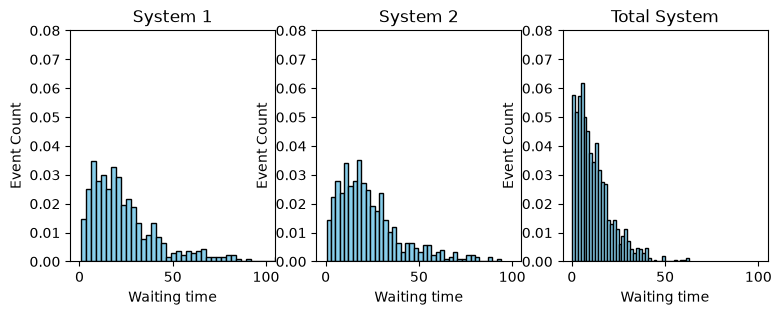

In [10]:
plt.figure(figsize=(9, 3.0))

plt.subplot(1,3,1)
plt.hist(wtime_1, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.08])
plt.title("System 1")
plt.xlabel("Waiting time")
plt.ylabel("Event Count")

plt.subplot(1,3,2)
plt.hist(wtime_2, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.08])
plt.title("System 2")
plt.xlabel("Waiting time")
plt.ylabel("Event Count")

plt.subplot(1,3,3)
plt.hist(wtime_all, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.08])
plt.title("Total System")
plt.xlabel("Waiting time")
plt.ylabel("Event Count")
plt.show()

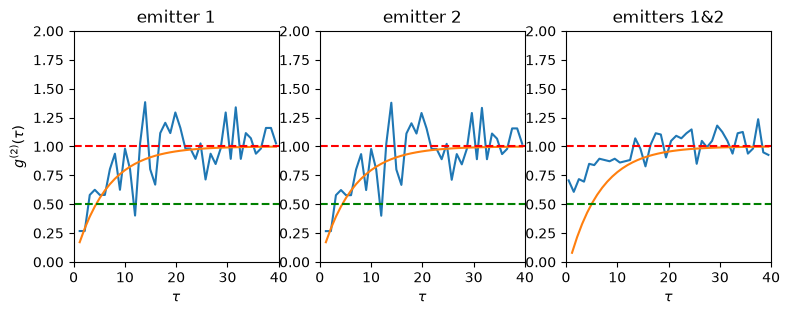

In [14]:
tau_max = 40  # max correlation time
dN = 10

def pair_times(spikes):

    time_gap = np.array([])
    i=1

    N_spikes = len(spikes)

    
    while i < N_spikes-dN:
        t0 = spikes[i]
        j = i+1
        while  (j < N_spikes) :
            t1 = spikes[j]
            if t1-t0 <= tau_max:
                time_gap = np.append(time_gap,t1-t0)
                j += 1
            else:
                break
        i += 1
        
    return time_gap

tgap_1 = pair_times(t_emission_1)
tgap_2 = pair_times(t_emission_2)
tgap_3 = pair_times(t_emission_all)

nbins = 40
dtau = tau_max/nbins

N_spikes=len(t_emission_1)
norm = (N_spikes-dN)*N_spikes /t_emission_1[N_spikes-1] * dtau 
counts, bin = np.histogram(tgap_1, bins=nbins)
n=len(bin)
x1 = (bin[0:n-1]+bin[1:n])/2
y1 = counts/norm

N_spikes=len(t_emission_2)
norm = (N_spikes-dN)*N_spikes /t_emission_2[N_spikes-1] * dtau 
counts, bin = np.histogram(tgap_1, bins=nbins)
n=len(bin)
x2 = (bin[0:n-1]+bin[1:n])/2
y2 = counts/norm

N_spikes=len(t_emission_all)
norm = (N_spikes-dN)*N_spikes /t_emission_all[N_spikes-1] * dtau 
counts, bin = np.histogram(tgap_3, bins=nbins)
n=len(bin)
x3 = (bin[0:n-1]+bin[1:n])/2
y3 = counts/norm


plt.figure(figsize=(9, 3))
plt.subplot(1,3,1)
plt.title("emitter 1")
g2_single = 1-np.exp(-gamma2*x1)
plt.ylim([0,2])
plt.plot(x1,y1)
plt.plot(x1,g2_single)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='r', linestyle='--')
plt.axhline(y=0.5, color='g', linestyle='--')

plt.subplot(1,3,2)
plt.title("emitter 2")
g2_single = 1-np.exp(-gamma2*x2)
plt.ylim([0,2])
plt.plot(x2,y2)
plt.plot(x1,g2_single)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel("")
plt.axhline(y=1, color='r', linestyle='--')
plt.axhline(y=0.5, color='g', linestyle='--')

plt.subplot(1,3,3)
plt.title("emitters 1&2")
g2_single = 1-np.exp(-gamma2*x3)
plt.ylim([0,2])
plt.plot(x3,y3)
plt.plot(x1,g2_single)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel("")
plt.axhline(y=1, color='r', linestyle='--')
plt.axhline(y=0.5, color='g', linestyle='--')
plt.show()

In the above plots, the orange curve is showing $g^{(2)}(\tau)$ for a single system.  The quantum trajectory from each system agrees with it.  However, the coherence function obtained from the combined data differs from it. The data still very noisy but the curve seems going to 0.5 at $\tau=0$.